# Vuln47 — Detecting Vulnerabilities in C/C++ Functions with Graph Neural Networks

## Notebook 00 — Theoretical Background & Problem Statement

> **Project goal:** given the source code of a single C/C++ function, predict whether it contains a security vulnerability. This is a **binary classification** task: *vulnerable* (`target = 1`) vs. *safe* (`target = 0`).

This notebook is the **theoretical foundation** of the project. It defines the problem, motivates why it matters, surveys previous research, and explains *why* a **graph-based representation of code + a Graph Neural Network (GNN)** was chosen rather than treating source code as flat text.

The project is organized as a sequence of notebooks:

| Notebook | Purpose |
|---|---|
| **`00_theoretical`** | Problem statement, related work, method rationale *(this notebook)* |
| `01_data_analyze` | Exploratory data analysis of the PrimeVul dataset |
| `02_data_preprocess` | Turning raw C code into graphs and tensors |
| `03_model_training` | Training the GNN |
| `04_model_testing` | Evaluation and comparison with prior work |
| `05_conclusion` | Findings, limitations, future work |

All heavy lifting lives in the reusable `source/` Python package; the notebooks import from it rather than duplicating logic.

## 1. The Problem — Why Automated Vulnerability Detection?

Software vulnerabilities in low-level languages like **C and C++** are among the most damaging and expensive classes of bugs in modern computing. Because C/C++ give the programmer manual control over memory, a single mistake — an off-by-one index, a missing bounds check, a use-after-free — can become a remotely exploitable security hole. Real incidents such as **Heartbleed** (a buffer over-read in OpenSSL, CVE-2014-0160) and countless Linux-kernel CVEs show how a *few lines inside one function* can compromise millions of systems.

The scale of the problem makes **manual code review insufficient**:

- Large projects (the Linux kernel, Chrome, QEMU) contain **millions of functions**, changing daily.
- Vulnerabilities are **rare** relative to the total amount of code — most functions are perfectly safe. This makes them hard to find, like needles in a haystack.
- Human reviewers are slow, expensive, and inconsistent.

### Problem definition (precise)

> **Input:** the raw source text of one C/C++ function.
> **Output:** a label $\hat{y} \in \{0, 1\}$, where $1$ means the function contains a vulnerability and $0$ means it does not.

This is a **supervised binary classification** problem. The goal is to learn a function $f_\theta$ (a neural network with parameters $\theta$) that maps code to a probability:

$$ \hat{y} = \mathbb{1}\big[\, f_\theta(\text{code}) \geq \tau \,\big], \qquad f_\theta(\text{code}) \in [0, 1] $$

where $\tau$ is a decision threshold.

### Why this is a *real* problem worth solving

- It targets an **authentic security-engineering need**: triaging which functions deserve a human's attention.
- The labels come from **real CVEs** in real open-source projects — not synthetic toy code.
- A good model acts as an **early-warning filter** in the development pipeline (e.g. a CI check on every pull request).

## 2. Previous Research

Learning-based vulnerability detection has evolved through three broad generations. The most relevant work is summarized below, and this project is positioned against it.

### 2.1 Token / sequence models
Early deep-learning approaches treated code as a **sequence of tokens** and applied RNNs/LSTMs or CNNs.

- **VulDeePecker** (Li et al., 2018) sliced programs into "code gadgets" (sequences of data-dependent statements) and fed them to a BiLSTM. It demonstrated that deep learning could beat hand-crafted rules, but the linear token view discards program structure.

### 2.2 Graph models
The key insight of the second generation is that **code is inherently structured** — it has syntax trees, control flow, and data flow. Representing code as a **graph** and learning over it with a GNN captures relationships that a flat sequence cannot.

- **Devign** (Zhou et al., 2019) built a joint graph from AST, control-flow, and data-flow edges and used a Gated Graph Neural Network. It showed clear gains over sequence models on real projects, establishing graphs as a strong representation for this task.
- **ReVeal** (Chakraborty et al., 2021) critically examined earlier datasets, exposed problems such as **duplication and unrealistic class balance**, and argued that reported accuracy was often inflated. It stressed the importance of *realistic evaluation* and handling **class imbalance**.

### 2.3 Cleaner benchmarks & the dataset used here
- **PrimeVul** (Ding et al., 2024) is a recent, carefully curated benchmark of real C/C++ functions. It addresses the labelling-noise and leakage problems that plagued earlier datasets by using stricter labelling and de-duplication, and it deliberately preserves the **natural (highly imbalanced) ratio** of vulnerable to safe functions. Its authors report that even strong models struggle under this realistic setting — a caution that raw accuracy is misleading here.

**This project builds directly on this line of work:** PrimeVul is adopted as the dataset (following ReVeal's and PrimeVul's emphasis on realistic evaluation), together with a graph + GNN model (following Devign's structural insight).

### 2.4 How this project compares to prior results
- Like **Devign**, each function is represented as a graph and classified with a GNN — but a modern **Graph Isomorphism Network (GIN)** with residual connections is used rather than a Gated GNN.
- Like **ReVeal** and **PrimeVul**, accuracy is *not reported alone*. Because ~2.5–2.8% of functions are vulnerable (see Notebook 01), a trivial "always safe" classifier scores ~97% accuracy while being useless. Evaluation therefore uses **F1, Precision, Recall, and PR-AUC** (Notebook 04), the metrics these papers advocate for imbalanced detection.

### References
1. Zhou, Y., Liu, S., Siow, J., Du, X., & Liu, Y. (2019). *Devign: Effective Vulnerability Identification by Learning Comprehensive Program Semantics via Graph Neural Networks.* NeurIPS.
2. Chakraborty, S., Krishna, R., Ding, Y., & Ray, B. (2021). *Deep Learning based Vulnerability Detection: Are We There Yet?* IEEE TSE (ReVeal).
3. Ding, Y., et al. (2024). *PrimeVul: Vulnerability Detection with Code Language Models.* (Dataset used in this project.)
4. Li, Z., et al. (2018). *VulDeePecker: A Deep Learning-Based System for Vulnerability Detection.* NDSS.
5. Xu, K., Hu, W., Leskovec, J., & Jegelka, S. (2019). *How Powerful are Graph Neural Networks?* ICLR. (The GIN architecture used here.)

## 3. Why Represent Code as a Graph?

A natural first instinct is to treat source code like natural-language text: a sequence of tokens fed to an NLP model. But code is **not** a linear story — it has rich structure that a flat sequence throws away:

- **Syntax** — nested expressions, blocks, and declarations form a tree (the Abstract Syntax Tree, AST).
- **Control flow** — `if`, `for`, `while`, `return` create branches and loops.
- **Data flow** — a variable written in one place is read in another, possibly far away in the text.

Two functions can look almost identical token-by-token yet differ in the one structural detail that makes one safe and the other exploitable. Consider:

```c
// SAFE: bounds are checked before the copy
void copy_safe(char *dst, const char *src, size_t n) {
    if (n < BUF_SIZE)          // <-- guard
        memcpy(dst, src, n);
}

// VULNERABLE: no guard -> possible buffer overflow
void copy_bad(char *dst, const char *src, size_t n) {
    memcpy(dst, src, n);       // <-- unchecked
}
```

The *tokens* are nearly the same. What distinguishes them is a **structural relationship**: in the safe version there is a control-flow edge placing the `memcpy` **inside** an `if` guard. A graph makes this relationship explicit and local; a token sequence buries it.

### The Abstract Syntax Tree (AST)
In this project the **AST** is used as the graph, produced by the `tree-sitter` parser (Notebook 02). Each node is a syntactic construct (a function definition, an `if` statement, a call expression, an identifier). Edges connect a parent construct to its children. This gives every function a graph $G = (V, E)$ where:

- $V$ = syntax nodes, each carrying a **type** (e.g. `if_statement`, `call_expression`) and, for leaves, a **token** (e.g. the identifier `memcpy`).
- $E$ = parent→child relationships.

The pipeline deliberately starts with the AST (always available, cheap to compute) and is designed so richer edges (control/data flow, as in Devign) can be added later.

### 3.1 Seeing it for real — parsing the two functions into ASTs

The cells below use the project's own `CodeGraphRepresentator` (from the `source/` package) to parse the two example functions into ASTs and draw them. Notice how the safe version has an extra `if_statement` node wrapping the `call_expression`.

In [1]:
import os
import sys

# make the project root importable so `source.` packages resolve from the notebooks/ folder
PROJECT_ROOT = os.getcwd()
while PROJECT_ROOT != "/" and not os.path.isdir(os.path.join(PROJECT_ROOT, "source")):
    PROJECT_ROOT = os.path.dirname(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import networkx as nx
import matplotlib.pyplot as plt

from source.preprocessing.data_preprocessing.data_representation.data_graph_representation.code_graph_representator import (
    CodeGraphRepresentator,
)

representator = CodeGraphRepresentator()

safe_code = """
void copy_safe(char *dst, const char *src, unsigned long n) {
    if (n < 256)
        memcpy(dst, src, n);
}
"""

vuln_code = """
void copy_bad(char *dst, const char *src, unsigned long n) {
    memcpy(dst, src, n);
}
"""

safe_graph = representator.represent(safe_code)
vuln_graph = representator.represent(vuln_code)

print(f"safe   -> {safe_graph.num_nodes} nodes, {len(safe_graph.edges)} edges")
print(f"vuln   -> {vuln_graph.num_nodes} nodes, {len(vuln_graph.edges)} edges")

safe   -> 31 nodes, 48 edges
vuln   -> 26 nodes, 40 edges


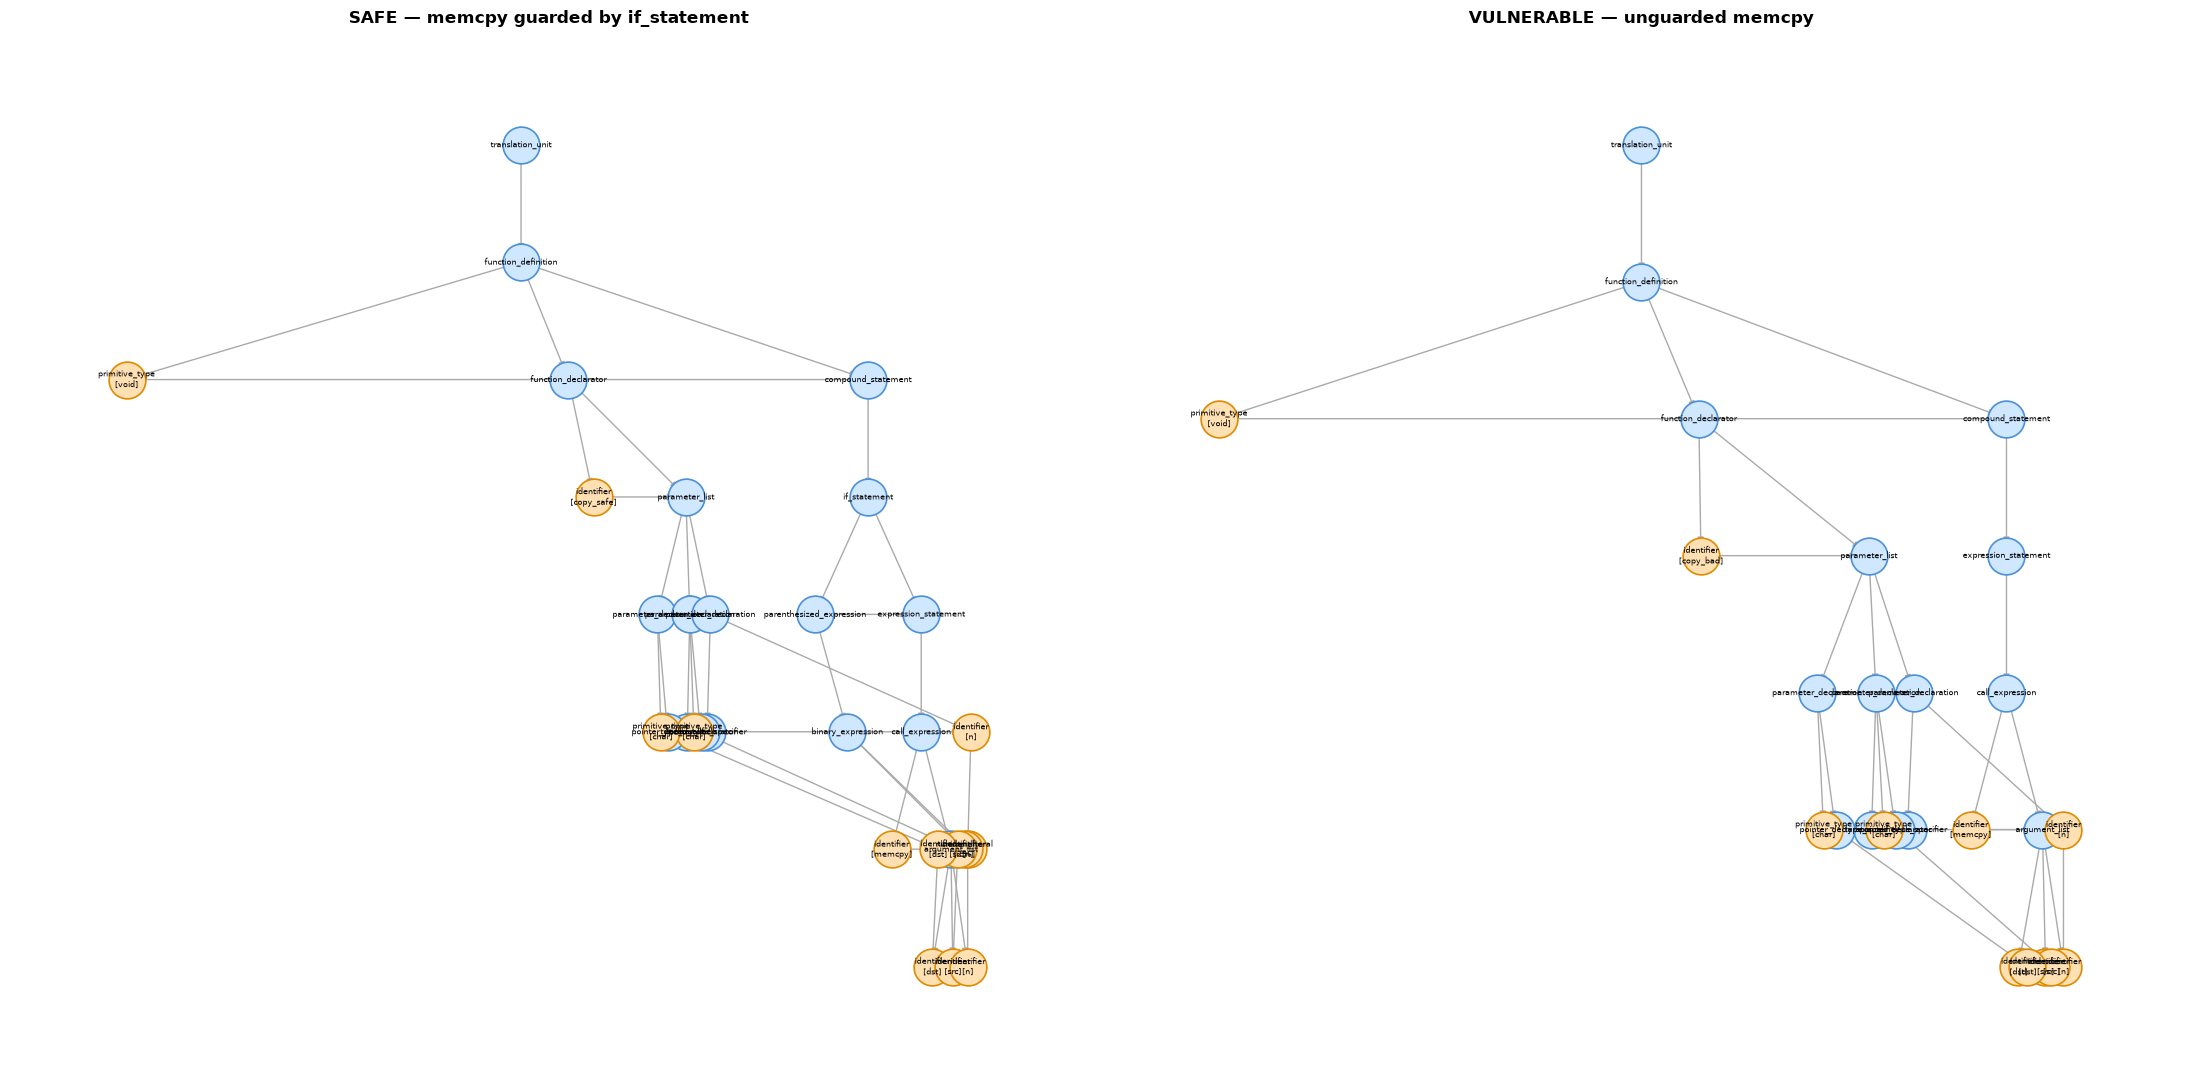

In [3]:
def _tidy_tree_pos(graph):
    """Compute non-overlapping tree positions: leaves spread evenly, parents centered over children."""
    g = nx.DiGraph()
    g.add_nodes_from(range(graph.num_nodes))
    g.add_edges_from(graph.edges)

    depth = nx.single_source_shortest_path_length(g, 0)
    children = {n: sorted(g.successors(n)) for n in g.nodes}

    x = {}
    counter = [0]

    def assign(node):
        kids = children[node]
        if not kids:                      # leaf: take the next free slot
            x[node] = counter[0]
            counter[0] += 1
        else:
            for k in kids:
                assign(k)
            x[node] = sum(x[k] for k in kids) / len(kids)   # center over children

    assign(0)
    return {n: (x[n], -depth[n]) for n in g.nodes}


def draw_ast(graph, ax, title):
    """Draw a CodeGraph as a hierarchical tree; label each node with its type (and token if present)."""
    g = nx.DiGraph()
    for i, ntype in enumerate(graph.node_types):
        token = graph.node_tokens[i]
        label = f"{ntype}\n[{token}]" if token else ntype
        g.add_node(i, label=label)
    g.add_edges_from(graph.edges)

    pos = _tidy_tree_pos(graph)

    leaf = [n for n in g.nodes if graph.node_tokens[n]]
    inner = [n for n in g.nodes if not graph.node_tokens[n]]

    labels = nx.get_node_attributes(g, "label")
    nx.draw_networkx_edges(g, pos, ax=ax, arrows=True, arrowsize=9, edge_color="#aaa")
    nx.draw_networkx_nodes(g, pos, ax=ax, nodelist=inner, node_color="#cfe8ff",
        edgecolors="#4a90d9", linewidths=1.2, node_size=700)
    nx.draw_networkx_nodes(g, pos, ax=ax, nodelist=leaf, node_color="#ffe0b3",
        edgecolors="#e08a00", linewidths=1.2, node_size=700)
    nx.draw_networkx_labels(g, pos, labels, ax=ax, font_size=6)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.margins(0.08)
    ax.axis("off")


fig, axes = plt.subplots(1, 2, figsize=(22, 11))
draw_ast(safe_graph, axes[0], "SAFE \u2014 memcpy guarded by if_statement")
draw_ast(vuln_graph, axes[1], "VULNERABLE \u2014 unguarded memcpy")
plt.tight_layout()
plt.show()

## 4. Graph Neural Networks — How the Model Learns

Once each function is a graph, a model that can learn from **graph-structured data** is needed. That is exactly what a **Graph Neural Network (GNN)** does.

### 4.1 The message-passing idea
A GNN learns a vector (an **embedding**) for every node by repeatedly **passing messages between neighbours**. At each layer $k$, a node updates its representation $h_v$ by aggregating the representations of its neighbours $\mathcal{N}(v)$:

$$ h_v^{(k)} = \text{UPDATE}^{(k)}\!\Big( h_v^{(k-1)},\; \text{AGGREGATE}^{(k)}\big(\{\, h_u^{(k-1)} : u \in \mathcal{N}(v) \,\}\big) \Big) $$

After $K$ layers, each node "knows about" its $K$-hop neighbourhood. Stacking layers lets information about, say, an `if` guard several hops away reach the `memcpy` node.

### 4.2 Which GNN — GIN (edge-aware)
This project uses the **Graph Isomorphism Network (GIN)** (Xu et al., 2019), which is provably one of the most expressive message-passing GNNs — it is as powerful as the Weisfeiler-Lehman graph-isomorphism test at distinguishing graph structures. Its update rule is:

$$ h_v^{(k)} = \text{MLP}^{(k)}\!\Big( (1 + \epsilon^{(k)}) \cdot h_v^{(k-1)} + \sum_{u \in \mathcal{N}(v)} h_u^{(k-1)} \Big) $$

where $\epsilon^{(k)}$ is a learnable scalar and $\text{MLP}$ is a small multi-layer perceptron. Because the graph carries **multiple edge types** (see §4.4), the model uses the edge-aware variant **GINE** (`GINEConv`), which adds a learned embedding of the edge type into each message. Expressiveness matters here because safe vs. vulnerable functions often differ by *subtle structural patterns*.

### 4.3 From node embeddings to a function-level label
A vulnerability is a property of the **whole function**, not a single node. So after message passing all node embeddings are **pooled** into one graph-level vector, then classified:

$$ h_G = \big[\; \text{mean}_{v}\, h_v^{(K)} \;\Vert\; \max_{v}\, h_v^{(K)} \;\big], \qquad \hat{y} = \text{softmax}\big(\text{MLP}(h_G)\big) $$

**Mean** pooling (overall tendency) and **max** pooling (the single most salient node) are concatenated so the classifier sees both the average and the extremes.

### 4.4 The architecture (`Vuln47GNN`)
The concrete model lives in `source/vuln47_gnn_model.py`. In one glance:

1. **Type embedding** — each node's syntactic type (e.g. `if_statement`) is mapped to a learned vector.
2. **Token embedding + features** — each leaf token is hashed into one of a fixed number of buckets and mapped to a learned embedding (so the model can learn token semantics without an external tokenizer), concatenated with 5 hand-crafted numeric features (e.g. *is this a known dangerous function like `strcpy`?*, token length, looks-like-a-size-variable, ...). Both are defined in `code_node_config.py`.
3. **Typed, bidirectional edges** — the AST is enriched with three edge types (parent→child, next-sibling, and a use→def chain linking repeated identifiers as a data-flow approximation), each made bidirectional; a learned **edge embedding** feeds these into the edge-aware **`GINEConv`** layers.
4. **4 GINE layers** with BatchNorm, ReLU, dropout, and **residual connections** ($h \leftarrow h + \text{GINE}(h)$) for stable deep training. A **JumpingKnowledge** readout then concatenates every layer's output, so the classifier sees features at all message-passing depths.
5. **mean + max pooling** → a 2-class classifier head.

This model is inspected in code in the next cell.

In [4]:
from source.vuln47_gnn_model import build_model
from source.preprocessing.data_preprocessing.data_representation.data_node_representation.code_node_representator import CodeNodeRepresentator

# the vocabulary of AST node types (built from the training split) sizes the type-embedding table
vocab = CodeNodeRepresentator.load_or_build_vocab()
model = build_model(vocab)

n_params = sum(p.numel() for p in model.parameters())
print(f"Vuln47GNN — {len(vocab)} node types, {n_params:,} trainable parameters\n")
print(model)

Vuln47GNN — 112 node types, 752,454 trainable parameters

Vuln47GNN(
  (type_emb): Embedding(112, 64)
  (token_emb): Embedding(4096, 32)
  (input_proj): Linear(in_features=101, out_features=192, bias=True)
  (edge_emb): Embedding(6, 192)
  (convs): ModuleList(
    (0-3): 4 x GINEConv(nn=Sequential(
      (0): Linear(in_features=192, out_features=192, bias=True)
      (1): ReLU()
      (2): Linear(in_features=192, out_features=192, bias=True)
    ))
  )
  (bns): ModuleList(
    (0-3): 4 x BatchNorm1d(192, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  )
  (jk): JumpingKnowledge(cat)
  (classifier): Sequential(
    (0): Linear(in_features=1536, out_features=192, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=192, out_features=2, bias=True)
  )
)


## 5. The Central Challenge — Class Imbalance & Honest Metrics

The single most important property of this problem is that **vulnerabilities are rare**. As Notebook 01 will show quantitatively, only **~2.2–2.8%** of functions in PrimeVul are vulnerable — a roughly **1 : 35–44** ratio.

### 5.1 Why accuracy is the wrong metric
A model that blindly predicts "safe" for *everything* achieves:

$$ \text{accuracy} \approx \frac{97.3\%\ \text{safe}}{100\%} = 97.3\% $$

…while catching **zero** vulnerabilities. High accuracy, useless model. This is precisely the trap ReVeal (2021) warned about.

### 5.2 The metrics used instead
The reported metrics focus on the **rare positive class**:

| Metric | Meaning | Why it matters here |
|---|---|---|
| **Precision** | of the functions flagged, how many are truly vulnerable | controls false alarms wasting reviewer time |
| **Recall** | of all vulnerable functions, how many are caught | controls missed vulnerabilities (the dangerous errors) |
| **F1** | harmonic mean of precision & recall | single balanced score |
| **PR-AUC** | area under the precision-recall curve | threshold-independent quality on imbalanced data |

$$ \text{Precision} = \frac{TP}{TP+FP}, \qquad \text{Recall} = \frac{TP}{TP+FN}, \qquad F_1 = \frac{2\cdot P \cdot R}{P + R} $$

### 5.3 How the imbalance is handled during training
Rather than resampling the data, the loss itself is made imbalance-aware in two complementary ways:

- **Class weighting** — mistakes on the rare *vulnerable* class are penalized ~35× more heavily than mistakes on the *safe* class (weight $\propto n_\text{safe}/n_\text{vuln}$).
- **Focal loss** — on top of the class weight, the loss down-weights *easy, already-confident* examples by a factor $(1 - p_t)^\gamma$ (with $\gamma = 2$), so training keeps focusing on the hard, still-misclassified functions rather than the vast pool of trivially-safe ones.

This keeps the *natural* data distribution (no synthetic duplication, no discarding of real safe functions). It is implemented in `source/training/model_training/loss/focal_loss.py`, wired up in `model_trainer.py`, and analysed in Notebook 03.

---

## 6. Roadmap of the Project

Putting the pieces together, the end-to-end pipeline is:

$$ \text{C code} \;\xrightarrow{\text{tree-sitter}}\; \text{AST graph} \;\xrightarrow{\text{node features}}\; \text{PyG } \texttt{Data} \;\xrightarrow{\text{GINE + pooling}}\; \hat{y} $$

Each arrow corresponds to a reusable component in the `source/` package and is documented in the following notebooks. With the theory in place, **Notebook 01** now looks at the data itself.